In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [24]:
housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = housing.target


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [25]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

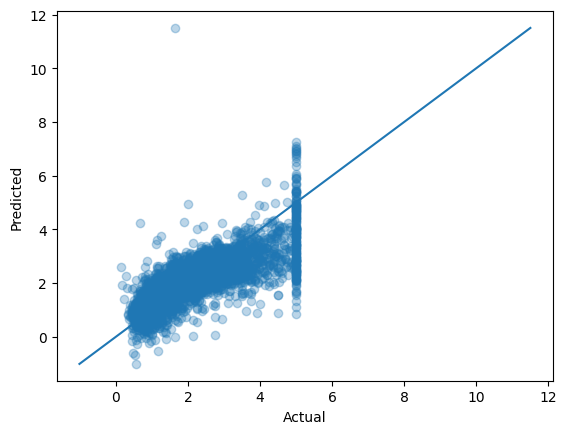

In [26]:
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.scatter(y_test, pred, alpha=0.3)
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [27]:
#R2 score (how much of the data is explained by the model)
r2 = r2_score(y_test, pred)
print(f"R² Score: {r2:.3f}")

#Root mean squared error (square root of differences between actual and predicted values lower = better)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f"RMSE: {rmse:.3f}\n")

#effect of attribute on house price (positive values raise the price, negative decreases)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients.sort_values(
    by="Coefficient",
    ascending=False
),"\n")

#actual vs predicted values (first ten values)
comparison = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": pred[:10]
})

print(comparison)


R² Score: 0.576
RMSE: 0.746

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708 

    Actual  Predicted
0  0.47700   0.719123
1  0.45800   1.764017
2  5.00001   2.709659
3  2.18600   2.838926
4  2.78000   2.604657
5  1.58700   2.011754
6  1.98200   2.645500
7  1.57500   2.168755
8  3.40000   2.740746
9  4.46600   3.915615


[-0.24212284 -1.30601657  2.29035117 -0.65292593  0.17534275 -0.42475367
 -0.66350005 -0.59375532  0.65925356  0.55038527]


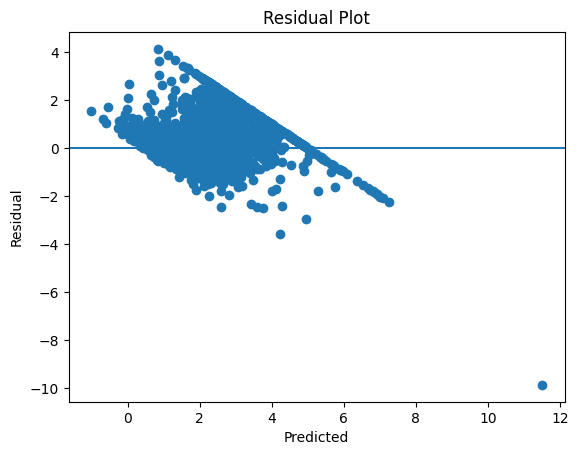

In [28]:
residuals = y_test - pred
print(residuals[:10])

plt.scatter(pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()